<a href="https://colab.research.google.com/github/Venkata-Prabhath/CNN_based-crowd-prediction/blob/main/Crowd_Risk_Prediction_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CELL 1 — UPLOAD KAGGLE API KEY
# ============================================================

from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [2]:
# ============================================================
# CELL 2 — CONFIGURE KAGGLE
# ============================================================

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle configured successfully.")

Kaggle configured successfully.


In [3]:
# ============================================================
# CELL 3 — DOWNLOAD SHANGHAITECH DATASET
# ============================================================

!kaggle datasets download -d tthien/shanghaitech

print("Dataset downloaded.")

Dataset URL: https://www.kaggle.com/datasets/tthien/shanghaitech
License(s): unknown
100% 333M/333M [00:02<00:00, 132MB/s]

Dataset downloaded.


In [4]:
# ============================================================
# CELL 4 — EXTRACT DATASET
# ============================================================

import os
import zipfile

zip_path = "shanghaitech.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("data")

print("Dataset extracted.")

Dataset extracted.


In [5]:
# ============================================================
# CELL 5 — VERIFY DATASET
# ============================================================

import os

for root, dirs, files_list in os.walk("data/ShanghaiTech"):
    print(root, len(files_list))

data/ShanghaiTech 0
data/ShanghaiTech/part_A 0
data/ShanghaiTech/part_A/test_data 0
data/ShanghaiTech/part_A/test_data/images 182
data/ShanghaiTech/part_A/test_data/ground-truth 182
data/ShanghaiTech/part_A/train_data 0
data/ShanghaiTech/part_A/train_data/images 300
data/ShanghaiTech/part_A/train_data/ground-truth 300
data/ShanghaiTech/part_B 0
data/ShanghaiTech/part_B/test_data 0
data/ShanghaiTech/part_B/test_data/images 316
data/ShanghaiTech/part_B/test_data/ground-truth 316
data/ShanghaiTech/part_B/train_data 0
data/ShanghaiTech/part_B/train_data/images 400
data/ShanghaiTech/part_B/train_data/ground-truth 400


In [6]:
# ============================================================
# CELL 6 — IMPORTS
# ============================================================

import os
import glob
import random
import time
import cv2
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter

import tensorflow as tf

from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D,
    Concatenate,
    ReLU,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    Resizing
)

from tensorflow.keras.applications import (
    VGG16,
    ResNet50,
    EfficientNetB0,
    MobileNetV2
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [7]:
# ============================================================
# CELL 7 — REPRODUCIBILITY AND GPU
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("GPU devices:")
print(tf.config.list_physical_devices("GPU"))

GPU devices:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
# ============================================================
# CELL 8 — DATASET PATHS
# ============================================================

DATASET_PATH = "data/ShanghaiTech/part_A"

TRAIN_IMAGE_PATH = os.path.join(
    DATASET_PATH,
    "train_data",
    "images"
)

TRAIN_GT_PATH = os.path.join(
    DATASET_PATH,
    "train_data",
    "ground-truth"
)

TEST_IMAGE_PATH = os.path.join(
    DATASET_PATH,
    "test_data",
    "images"
)

TEST_GT_PATH = os.path.join(
    DATASET_PATH,
    "test_data",
    "ground-truth"
)

train_images = sorted(
    glob.glob(os.path.join(TRAIN_IMAGE_PATH, "*.jpg"))
)

test_images = sorted(
    glob.glob(os.path.join(TEST_IMAGE_PATH, "*.jpg"))
)

print("Training images:", len(train_images))
print("Testing images :", len(test_images))

Training images: 300
Testing images : 182


In [9]:
# ============================================================
# CELL 9 — LOAD IMAGE AND ANNOTATIONS
# ============================================================

def get_gt_path(image_path):
    """
    Return corresponding ShanghaiTech ground-truth path.
    """

    if "train_data" in image_path:
        gt_folder = TRAIN_GT_PATH
    else:
        gt_folder = TEST_GT_PATH

    filename = os.path.basename(image_path)

    gt_name = (
        filename
        .replace("IMG_", "GT_IMG_")
        .replace(".jpg", ".mat")
    )

    return os.path.join(gt_folder, gt_name)


def load_image_and_points(image_path):
    image = cv2.imread(image_path)

    if image is None:
        raise FileNotFoundError(image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    gt_path = get_gt_path(image_path)

    mat = scipy.io.loadmat(gt_path)

    points = mat["image_info"][0][0][0][0][0]

    points = np.asarray(
        points,
        dtype=np.float32
    )

    return image, points

In [10]:
# ============================================================
# CELL 10 — TEST DATA LOADING
# ============================================================

sample_image, sample_points = load_image_and_points(
    train_images[0]
)

print("Image shape:", sample_image.shape)
print("People:", len(sample_points))
print("First points:")
print(sample_points[:5])

Image shape: (768, 1024, 3)
People: 1546
First points:
[[ 29.62251  472.92023 ]
 [ 54.355335 454.96603 ]
 [ 51.79045  460.46222 ]
 [ 51.79045  465.77518 ]
 [ 50.87442  473.65305 ]]


In [11]:
# ============================================================
# CELL 11 — DENSITY MAP GENERATION
# ============================================================

def generate_density_map(
    image_shape,
    points,
    sigma=4
):
    """
    Generate density map from head annotations.
    """

    height, width = image_shape[:2]

    density = np.zeros(
        (height, width),
        dtype=np.float32
    )

    for x, y in points:

        x = int(round(x))
        y = int(round(y))

        x = max(
            0,
            min(width - 1, x)
        )

        y = max(
            0,
            min(height - 1, y)
        )

        density[y, x] += 1.0

    density = gaussian_filter(
        density,
        sigma=sigma
    )

    return density

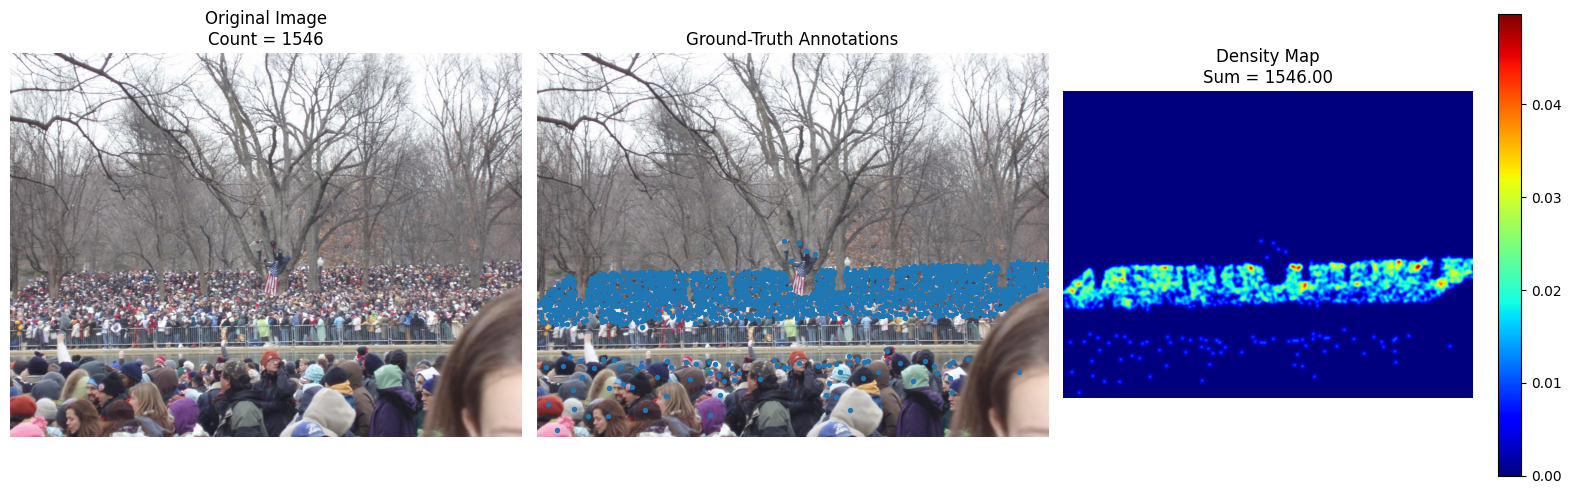

In [12]:
# ============================================================
# CELL 12 — VISUALIZE DENSITY MAP
# ============================================================

sample_density = generate_density_map(
    sample_image.shape,
    sample_points
)

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(sample_image)
plt.title(
    f"Original Image\nCount = {len(sample_points)}"
)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sample_image)
plt.scatter(
    sample_points[:, 0],
    sample_points[:, 1],
    s=8
)
plt.title("Ground-Truth Annotations")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(
    sample_density,
    cmap="jet"
)
plt.colorbar()
plt.title(
    f"Density Map\nSum = {sample_density.sum():.2f}"
)
plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# CELL 13 — PREPROCESSING CONFIGURATION
# ============================================================

IMAGE_SIZE = 256
DENSITY_SIZE = 64

BATCH_SIZE = 4

EPOCHS = 10

print("Image size:", IMAGE_SIZE)
print("Density size:", DENSITY_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: 256
Density size: 64
Batch size: 4


In [14]:
# ============================================================
# CELL 14 — PREPROCESS IMAGE AND DENSITY
# ============================================================

def preprocess_image_density(
    image,
    density
):
    # Resize image
    image_resized = cv2.resize(
        image,
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=cv2.INTER_AREA
    )

    # Resize density
    density_resized = cv2.resize(
        density,
        (DENSITY_SIZE, DENSITY_SIZE),
        interpolation=cv2.INTER_AREA
    )

    # Preserve total count
    original_count = density.sum()

    new_sum = density_resized.sum()

    if new_sum > 0:
        density_resized *= (
            original_count /
            new_sum
        )

    image_resized = (
        image_resized.astype(np.float32)
        / 255.0
    )

    density_resized = (
        density_resized.astype(np.float32)
    )

    density_resized = np.expand_dims(
        density_resized,
        axis=-1
    )

    return image_resized, density_resized

In [15]:
# ============================================================
# CELL 15 — TEST PREPROCESSING
# ============================================================

x_sample, y_sample = preprocess_image_density(
    sample_image,
    sample_density
)

print("Image:", x_sample.shape)
print("Density:", y_sample.shape)

print(
    "Original count:",
    sample_density.sum()
)

print(
    "Processed density sum:",
    y_sample.sum()
)

Image: (256, 256, 3)
Density: (64, 64, 1)
Original count: 1546.0
Processed density sum: 1546.0


In [16]:
# ============================================================
# CELL 16 — CREATE DATA GENERATOR
# ============================================================

def data_generator(
    image_paths,
    batch_size=4,
    shuffle=True
):

    image_paths = list(image_paths)

    while True:

        if shuffle:
            random.shuffle(image_paths)

        for start in range(
            0,
            len(image_paths),
            batch_size
        ):

            batch_paths = image_paths[
                start:start + batch_size
            ]

            X_batch = []
            Y_batch = []

            for path in batch_paths:

                image, points = (
                    load_image_and_points(path)
                )

                density = generate_density_map(
                    image.shape,
                    points
                )

                image, density = (
                    preprocess_image_density(
                        image,
                        density
                    )
                )

                X_batch.append(image)
                Y_batch.append(density)

            yield (
                np.array(
                    X_batch,
                    dtype=np.float32
                ),
                np.array(
                    Y_batch,
                    dtype=np.float32
                )
            )

In [17]:
# ============================================================
# CELL 17 — TRAIN / VALIDATION SPLIT
# ============================================================

random.seed(SEED)

all_train_images = train_images.copy()

random.shuffle(all_train_images)

split_index = int(
    len(all_train_images) * 0.8
)

train_paths = all_train_images[
    :split_index
]

val_paths = all_train_images[
    split_index:
]

print("Training:", len(train_paths))
print("Validation:", len(val_paths))
print("Testing:", len(test_images))

Training: 240
Validation: 60
Testing: 182


In [18]:
# ============================================================
# CELL 18 — DATASET OBJECTS
# ============================================================

train_generator = data_generator(
    train_paths,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_generator = data_generator(
    val_paths,
    batch_size=BATCH_SIZE,
    shuffle=False
)

train_steps = max(
    1,
    len(train_paths) // BATCH_SIZE
)

val_steps = max(
    1,
    len(val_paths) // BATCH_SIZE
)

print("Train steps:", train_steps)
print("Validation steps:", val_steps)

Train steps: 60
Validation steps: 15


In [19]:
# ============================================================
# CELL 19 — MCNN MODEL
# ============================================================

def build_mcnn():

    inputs = Input(
        shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
    )

    # Column 1
    c1 = Conv2D(
        16,
        9,
        padding="same",
        activation="relu"
    )(inputs)

    c1 = MaxPooling2D(2)(c1)

    c1 = Conv2D(
        32,
        7,
        padding="same",
        activation="relu"
    )(c1)

    # Column 2
    c2 = Conv2D(
        20,
        7,
        padding="same",
        activation="relu"
    )(inputs)

    c2 = MaxPooling2D(2)(c2)

    c2 = Conv2D(
        40,
        5,
        padding="same",
        activation="relu"
    )(c2)

    # Column 3
    c3 = Conv2D(
        24,
        5,
        padding="same",
        activation="relu"
    )(inputs)

    c3 = MaxPooling2D(2)(c3)

    c3 = Conv2D(
        48,
        3,
        padding="same",
        activation="relu"
    )(c3)

    x = Concatenate()(
        [c1, c2, c3]
    )

    x = Conv2D(
        64,
        3,
        padding="same",
        activation="relu"
    )(x)

    x = Conv2D(
        32,
        3,
        padding="same",
        activation="relu"
    )(x)

    output = Conv2D(
        1,
        1,
        padding="same",
        activation="relu"
    )(x)

    # 128 x 128 -> 64 x 64
    output = tf.keras.layers.Resizing(
        DENSITY_SIZE,
        DENSITY_SIZE
    )(output)

    model = Model(
        inputs,
        output,
        name="MCNN"
    )

    return model


mcnn = build_mcnn()

mcnn.summary()

Model: "MCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      3,904 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │      2,960 │ input_layer[0][0] │
│                     │ 20)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 256, 256,  │      1,824 │ input_layer[0][0] │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 20)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 128, 128,  │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     25,120 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     20,040 │ max_pooling2d_1[… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │     10,416 │ max_pooling2d_2[… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ conv2d_1[0][0],   │
│ (Concatenate)       │ 120)              │            │ conv2d_3[0][0],   │
│                     │                   │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │     69,184 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │     18,464 │ conv2d_6[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │         33 │ conv2d_7[0][0]    │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 64, 64, 1) │          0 │ conv2d_8[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 151,945 (593.54 KB)

 Trainable params: 151,945 (593.54 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# ============================================================
# CELL 20 — COMPILE MCNN
# ============================================================

mcnn.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="mse",
    metrics=["mae"]
)

print("MCNN compiled.")

MCNN compiled.


In [21]:
# ============================================================
# CELL 21 — TRAIN MCNN
# ============================================================

mcnn_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2
    )
]

mcnn_history = mcnn.fit(
    train_generator,
    steps_per_epoch=train_steps,
    validation_data=val_generator,
    validation_steps=val_steps,
    epochs=EPOCHS,
    callbacks=mcnn_callbacks
)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 222ms/step - loss: 0.1282 - mae: 0.1777 - val_loss: 0.1195 - val_mae: 0.1922 - learning_rate: 1.0000e-04
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 195ms/step - loss: 0.1200 - mae: 0.1647 - val_loss: 0.1181 - val_mae: 0.2087 - learning_rate: 1.0000e-04
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 194ms/step - loss: 0.1176 - mae: 0.1623 - val_loss: 0.1100 - val_mae: 0.1775 - learning_rate: 1.0000e-04
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 189ms/step - loss: 0.1113 - mae: 0.1532 - val_loss: 0.1218 - val_mae: 0.1313 - learning_rate: 1.0000e-04
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 180ms/step - loss: 0.1093 - mae: 0.1443 - val_loss: 0.1060 - val_mae: 0.1319 - learning_rate: 1.0000e-04
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 181ms/step - loss: 0.1056 - mae: 0.1437 - val_loss: 0.1000 - val_mae: 0.1509 - learning_rate: 1.0000e-04
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 182ms/step - loss: 0.1063 - mae: 0.1390 - val_loss: 0.0998 - val_mae: 0.1506

In [22]:
# ============================================================
# CELL 22 — CSRNET MODEL
# ============================================================

def build_csrnet():

    inputs = Input(
        shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
    )

    backbone = VGG16(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs
    )

    for layer in backbone.layers:
        layer.trainable = False

    x = backbone.get_layer(
        "block4_conv3"
    ).output

    x = Conv2D(
        512,
        3,
        padding="same",
        dilation_rate=2,
        activation="relu"
    )(x)

    x = Conv2D(
        512,
        3,
        padding="same",
        dilation_rate=2,
        activation="relu"
    )(x)

    x = Conv2D(
        256,
        3,
        padding="same",
        dilation_rate=2,
        activation="relu"
    )(x)

    x = Conv2D(
        128,
        3,
        padding="same",
        dilation_rate=2,
        activation="relu"
    )(x)

    x = Conv2D(
        64,
        3,
        padding="same",
        activation="relu"
    )(x)

    output = Conv2D(
        1,
        1,
        padding="same",
        activation="relu"
    )(x)

    output = tf.keras.layers.Resizing(
        DENSITY_SIZE,
        DENSITY_SIZE
    )(output)

    model = Model(
        inputs,
        output,
        name="CSRNet"
    )

    return model


csrnet = build_csrnet()

csrnet.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "CSRNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 256)    │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 1)      │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_1 (Resizing)           │ (None, 64, 64, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,903,681 (53.04 MB)

 Trainable params: 6,268,417 (23.91 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [23]:
# ============================================================
# CELL 23 — COMPILE CSRNET
# ============================================================

csrnet.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="mse",
    metrics=["mae"]
)

print("CSRNet compiled.")

CSRNet compiled.


In [24]:
# ============================================================
# CELL 24 — TRAIN CSRNET
# ============================================================

csr_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2
    )
]

csr_history = csrnet.fit(
    train_generator,
    steps_per_epoch=train_steps,
    validation_data=val_generator,
    validation_steps=val_steps,
    epochs=EPOCHS,
    callbacks=csr_callbacks
)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 26s 233ms/step - loss: 0.1513 - mae: 0.1383 - val_loss: 0.1443 - val_mae: 0.1431 - learning_rate: 1.0000e-04
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 192ms/step - loss: 0.1397 - mae: 0.1270 - val_loss: 0.1443 - val_mae: 0.1431 - learning_rate: 1.0000e-04
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 196ms/step - loss: 0.1568 - mae: 0.1325 - val_loss: 0.1443 - val_mae: 0.1431 - learning_rate: 1.0000e-04
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 201ms/step - loss: 0.1196 - mae: 0.1230 - val_loss: 0.1443 - val_mae: 0.1431 - learning_rate: 5.0000e-05


In [25]:
# ============================================================
# CELL 25 — GENERIC CNN BACKBONE DENSITY MODEL
# ============================================================

def build_backbone_density_model(
    backbone_name
):

    inputs = Input(
        shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
    )

    if backbone_name == "ResNet50":

        backbone = ResNet50(
            include_top=False,
            weights="imagenet",
            input_tensor=inputs
        )

    elif backbone_name == "EfficientNetB0":

        backbone = EfficientNetB0(
            include_top=False,
            weights="imagenet",
            input_tensor=inputs
        )

    elif backbone_name == "MobileNetV2":

        backbone = MobileNetV2(
            include_top=False,
            weights="imagenet",
            input_tensor=inputs
        )

    else:
        raise ValueError(
            "Unknown backbone"
        )

    for layer in backbone.layers:
        layer.trainable = False

    x = backbone.output

    x = Conv2D(
        256,
        3,
        padding="same",
        activation="relu"
    )(x)

    x = Conv2D(
        128,
        3,
        padding="same",
        activation="relu"
    )(x)

    x = Conv2D(
        64,
        3,
        padding="same",
        activation="relu"
    )(x)

    x = Conv2D(
        1,
        1,
        padding="same",
        activation="relu"
    )(x)

    x = tf.keras.layers.Resizing(
        DENSITY_SIZE,
        DENSITY_SIZE
    )(x)

    model = Model(
        inputs,
        x,
        name=backbone_name + "_Density"
    )

    return model

In [26]:
# ============================================================
# CELL 26 — RESNET50 MODEL
# ============================================================

resnet50_model = build_backbone_density_model(
    "ResNet50"
)

resnet50_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="mse",
    metrics=["mae"]
)

resnet50_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "ResNet50_Density"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 28,675,457 (109.39 MB)

 Trainable params: 5,087,745 (19.41 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [27]:
# ============================================================
# CELL 27 — TRAIN RESNET50
# ============================================================

resnet_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2
    )
]

resnet_history = resnet50_model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    validation_data=val_generator,
    validation_steps=val_steps,
    epochs=EPOCHS,
    callbacks=resnet_callbacks
)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 29s 271ms/step - loss: 0.1558 - mae: 0.1307 - val_loss: 0.1443 - val_mae: 0.1431 - learning_rate: 1.0000e-04
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 193ms/step - loss: 0.1557 - mae: 0.1301 - val_loss: 0.1443 - val_mae: 0.1431 - learning_rate: 1.0000e-04
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 198ms/step - loss: 0.1194 - mae: 0.1279 - val_loss: 0.1443 - val_mae: 0.1431 - learning_rate: 1.0000e-04
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 198ms/step - loss: 0.1620 - mae: 0.1285 - val_loss: 0.1443 - val_mae: 0.1431 - learning_rate: 5.0000e-05


In [28]:
# ============================================================
# CELL 28 — EFFICIENTNET-B0 MODEL
# ============================================================

efficientnet_model = build_backbone_density_model(
    "EfficientNetB0"
)

efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="mse",
    metrics=["mae"]
)

efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_Density"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 256, 256,  │          0 │ input_layer_3[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 256, 256,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 256, 256,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 257, 257,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 128, 128,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 128, 128,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 128, 128,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 128, 128,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 128, 128,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 128, 128,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 128, 128,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 128, 128,  │        512 │ block1a_se_excit

 Total params: 7,367,844 (28.11 MB)

 Trainable params: 3,318,273 (12.66 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [29]:
# ============================================================
# CELL 29 — TRAIN EFFICIENTNET-B0
# ============================================================

efficient_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2
    )
]

efficient_history = efficientnet_model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    validation_data=val_generator,
    validation_steps=val_steps,
    epochs=EPOCHS,
    callbacks=efficient_callbacks
)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 47s 332ms/step - loss: 0.1538 - mae: 0.1431 - val_loss: 0.1443 - val_mae: 0.1431 - learning_rate: 1.0000e-04
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - loss: 0.1406 - mae: 0.1287 - val_loss: 0.1443 - val_mae: 0.1431 - learning_rate: 1.0000e-04
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 334ms/step - loss: 0.1430 - mae: 0.1275 - val_loss: 0.1443 - val_mae: 0.1431 - learning_rate: 1.0000e-04
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 190ms/step - loss: 0.1528 - mae: 0.1315 - val_loss: 0.1443 - val_mae: 0.1431 - learning_rate: 5.0000e-05


In [30]:
# ============================================================
# CELL 30 — MOBILENETV2 MODEL
# ============================================================

mobilenet_model = build_backbone_density_model(
    "MobileNetV2"
)

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="mse",
    metrics=["mae"]
)

mobilenet_model.summary()

/tmp/ipykernel_2540/2896252692.py:31: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Density"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 5,576,257 (21.27 MB)

 Trainable params: 3,318,273 (12.66 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [31]:
# ============================================================
# CELL 31 — TRAIN MOBILENETV2
# ============================================================

mobile_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2
    )
]

mobile_history = mobilenet_model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    validation_data=val_generator,
    validation_steps=val_steps,
    epochs=EPOCHS,
    callbacks=mobile_callbacks
)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 34s 286ms/step - loss: 0.1518 - mae: 0.1388 - val_loss: 0.1443 - val_mae: 0.1431 - learning_rate: 1.0000e-04
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 179ms/step - loss: 0.1545 - mae: 0.1324 - val_loss: 0.1443 - val_mae: 0.1431 - learning_rate: 1.0000e-04
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 185ms/step - loss: 0.1311 - mae: 0.1233 - val_loss: 0.1443 - val_mae: 0.1431 - learning_rate: 1.0000e-04
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 194ms/step - loss: 0.1456 - mae: 0.1294 - val_loss: 0.1443 - val_mae: 0.1431 - learning_rate: 5.0000e-05


In [32]:
# ============================================================
# CELL 32 — COUNT PREDICTION FUNCTION
# ============================================================

def predict_count(
    model,
    image_path
):

    image, points = load_image_and_points(
        image_path
    )

    density = generate_density_map(
        image.shape,
        points
    )

    image_input, _ = (
        preprocess_image_density(
            image,
            density
        )
    )

    image_input = np.expand_dims(
        image_input,
        axis=0
    )

    start = time.perf_counter()

    prediction = model.predict(
        image_input,
        verbose=0
    )

    inference_time = (
        time.perf_counter()
        - start
    )

    predicted_count = float(
        prediction.sum()
    )

    true_count = float(
        len(points)
    )

    return (
        predicted_count,
        true_count,
        inference_time,
        image,
        prediction[0]
    )

In [33]:
# ============================================================
# CELL 33 — EVALUATE ONE MODEL
# ============================================================

def evaluate_model(
    model,
    image_paths
):

    true_counts = []
    predicted_counts = []
    inference_times = []

    for path in image_paths:

        pred_count, true_count, inference_time, _, _ = (
            predict_count(
                model,
                path
            )
        )

        true_counts.append(
            true_count
        )

        predicted_counts.append(
            pred_count
        )

        inference_times.append(
            inference_time
        )

    true_counts = np.array(
        true_counts
    )

    predicted_counts = np.array(
        predicted_counts
    )

    mae = np.mean(
        np.abs(
            true_counts -
            predicted_counts
        )
    )

    rmse = np.sqrt(
        np.mean(
            (
                true_counts -
                predicted_counts
            ) ** 2
        )
    )

    inference_time = np.mean(
        inference_times
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "Inference Time (s)": inference_time
    }

In [34]:
# ============================================================
# CELL 34 — EVALUATE MCNN
# ============================================================

mcnn_results = evaluate_model(
    mcnn,
    test_images
)

print("MCNN")
print(
    f"MAE  : {mcnn_results['MAE']:.2f}"
)
print(
    f"RMSE : {mcnn_results['RMSE']:.2f}"
)
print(
    f"Time : {mcnn_results['Inference Time (s)']:.4f} s"
)

MCNN
MAE  : 200.40
RMSE : 269.32
Time : 0.0835 s


In [35]:
# ============================================================
# CELL 35 — EVALUATE CSRNET
# ============================================================

csr_results = evaluate_model(
    csrnet,
    test_images
)

print("CSRNet")
print(
    f"MAE  : {csr_results['MAE']:.2f}"
)
print(
    f"RMSE : {csr_results['RMSE']:.2f}"
)
print(
    f"Time : {csr_results['Inference Time (s)']:.4f} s"
)

CSRNet
MAE  : 433.31
RMSE : 559.19
Time : 0.1140 s


In [36]:
# ============================================================
# CELL 36 — EVALUATE RESNET50
# ============================================================

resnet_results = evaluate_model(
    resnet50_model,
    test_images
)

print("ResNet50")
print(
    f"MAE  : {resnet_results['MAE']:.2f}"
)
print(
    f"RMSE : {resnet_results['RMSE']:.2f}"
)
print(
    f"Time : {resnet_results['Inference Time (s)']:.4f} s"
)

ResNet50
MAE  : 433.31
RMSE : 559.19
Time : 0.1162 s


In [37]:
# ============================================================
# CELL 37 — EVALUATE EFFICIENTNET-B0
# ============================================================

efficient_results = evaluate_model(
    efficientnet_model,
    test_images
)

print("EfficientNet-B0")
print(
    f"MAE  : {efficient_results['MAE']:.2f}"
)
print(
    f"RMSE : {efficient_results['RMSE']:.2f}"
)
print(
    f"Time : {efficient_results['Inference Time (s)']:.4f} s"
)

EfficientNet-B0
MAE  : 433.31
RMSE : 559.19
Time : 0.1444 s


In [38]:
# ============================================================
# CELL 38 — EVALUATE MOBILENETV2
# ============================================================

mobile_results = evaluate_model(
    mobilenet_model,
    test_images
)

print("MobileNetV2")
print(
    f"MAE  : {mobile_results['MAE']:.2f}"
)
print(
    f"RMSE : {mobile_results['RMSE']:.2f}"
)
print(
    f"Time : {mobile_results['Inference Time (s)']:.4f} s"
)

MobileNetV2
MAE  : 433.31
RMSE : 559.19
Time : 0.1453 s


In [39]:
# ============================================================
# CELL 39 — FINAL CROWD COUNTING COMPARISON
# ============================================================

comparison_df = pd.DataFrame({

    "Model": [
        "MCNN",
        "CSRNet",
        "ResNet50",
        "EfficientNet-B0",
        "MobileNetV2"
    ],

    "MAE": [
        mcnn_results["MAE"],
        csr_results["MAE"],
        resnet_results["MAE"],
        efficient_results["MAE"],
        mobile_results["MAE"]
    ],

    "RMSE": [
        mcnn_results["RMSE"],
        csr_results["RMSE"],
        resnet_results["RMSE"],
        efficient_results["RMSE"],
        mobile_results["RMSE"]
    ],

    "Inference Time (s)": [
        mcnn_results["Inference Time (s)"],
        csr_results["Inference Time (s)"],
        resnet_results["Inference Time (s)"],
        efficient_results["Inference Time (s)"],
        mobile_results["Inference Time (s)"]
    ]
})

comparison_df

,Model,MAE,RMSE,Inference Time (s)
0,MCNN,200.402226,269.316862,0.083485
1,CSRNet,433.307692,559.188865,0.113968
2,ResNet50,433.307692,559.188865,0.116191
3,EfficientNet-B0,433.307692,559.188865,0.144367
4,MobileNetV2,433.307692,559.188865,0.145309


In [40]:
# ============================================================
# CELL 40 — SORT MODELS BY MAE
# ============================================================

comparison_df = comparison_df.sort_values(
    by="MAE",
    ascending=True
).reset_index(drop=True)

print("Crowd Counting Model Ranking")
display(comparison_df)

Crowd Counting Model Ranking


,Model,MAE,RMSE,Inference Time (s)
0,MCNN,200.402226,269.316862,0.083485
1,CSRNet,433.307692,559.188865,0.113968
2,ResNet50,433.307692,559.188865,0.116191
3,EfficientNet-B0,433.307692,559.188865,0.144367
4,MobileNetV2,433.307692,559.188865,0.145309


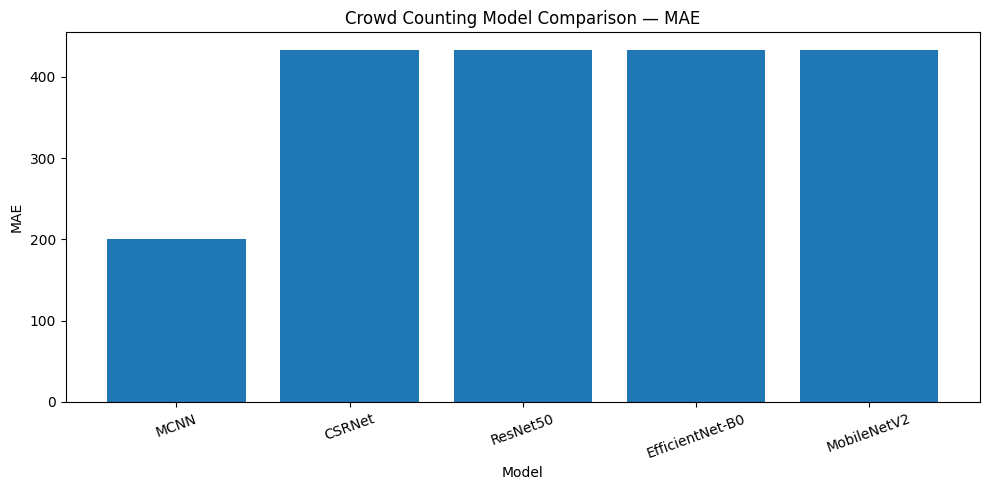

In [41]:
# ============================================================
# CELL 41 — PLOT MAE COMPARISON
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["MAE"]
)

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("Crowd Counting Model Comparison — MAE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

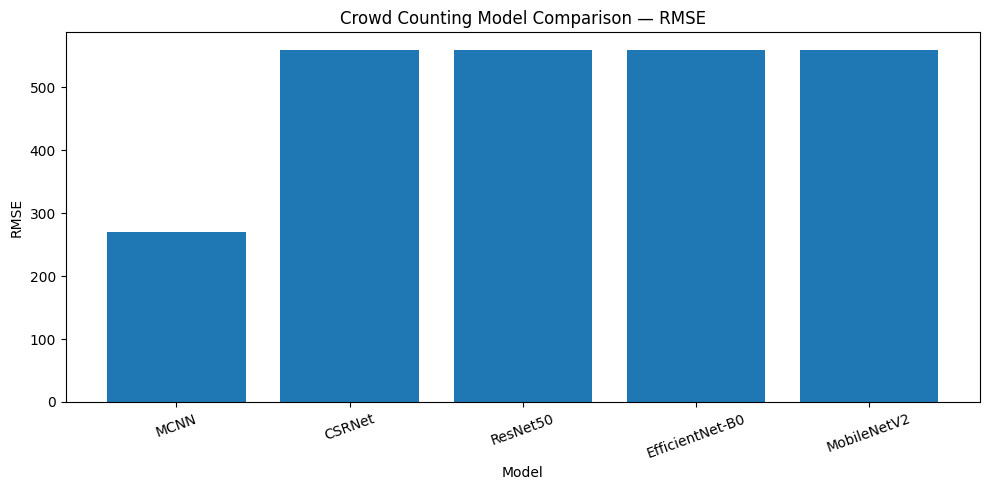

In [42]:
# ============================================================
# CELL 42 — PLOT RMSE COMPARISON
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Crowd Counting Model Comparison — RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [43]:
# ============================================================
# CELL 43 — RISK CLASSIFICATION
# ============================================================

def classify_risk(count):

    if count < 100:
        return "Green"

    elif count < 300:
        return "Orange"

    else:
        return "Red"


def risk_description(risk):

    if risk == "Green":
        return "Safe Crowd"

    elif risk == "Orange":
        return "Moderate Risk"

    else:
        return "High Crowd Risk"

In [44]:
# ============================================================
# CELL 44 — TEST RISK CLASSIFICATION
# ============================================================

for count in [50, 150, 350]:

    risk = classify_risk(count)

    print(
        count,
        "->",
        risk,
        "->",
        risk_description(risk)
    )

50 -> Green -> Safe Crowd
150 -> Orange -> Moderate Risk
350 -> Red -> High Crowd Risk


In [45]:
# ============================================================
# CELL 45 — SELECT BEST COUNTING MODEL
# ============================================================

model_objects = {
    "MCNN": mcnn,
    "CSRNet": csrnet,
    "ResNet50": resnet50_model,
    "EfficientNet-B0": efficientnet_model,
    "MobileNetV2": mobilenet_model
}

best_model_name = comparison_df.iloc[0]["Model"]

best_model = model_objects[
    best_model_name
]

print(
    "Best model:",
    best_model_name
)

Best model: MCNN


In [46]:
# ============================================================
# CELL 46 — BEST MODEL PREDICTION
# ============================================================

test_index = random.randint(
    0,
    len(test_images) - 1
)

selected_path = test_images[
    test_index
]

pred_count, gt_count, inference_time, original_image, pred_density = (
    predict_count(
        best_model,
        selected_path
    )
)

risk = classify_risk(
    pred_count
)

print("Model:", best_model_name)
print("Ground Truth Count:", gt_count)
print("Predicted Count:", round(pred_count, 2))
print("Risk:", risk)
print("Risk Description:", risk_description(risk))

Model: MCNN
Ground Truth Count: 379.0
Predicted Count: 601.78
Risk: Red
Risk Description: High Crowd Risk


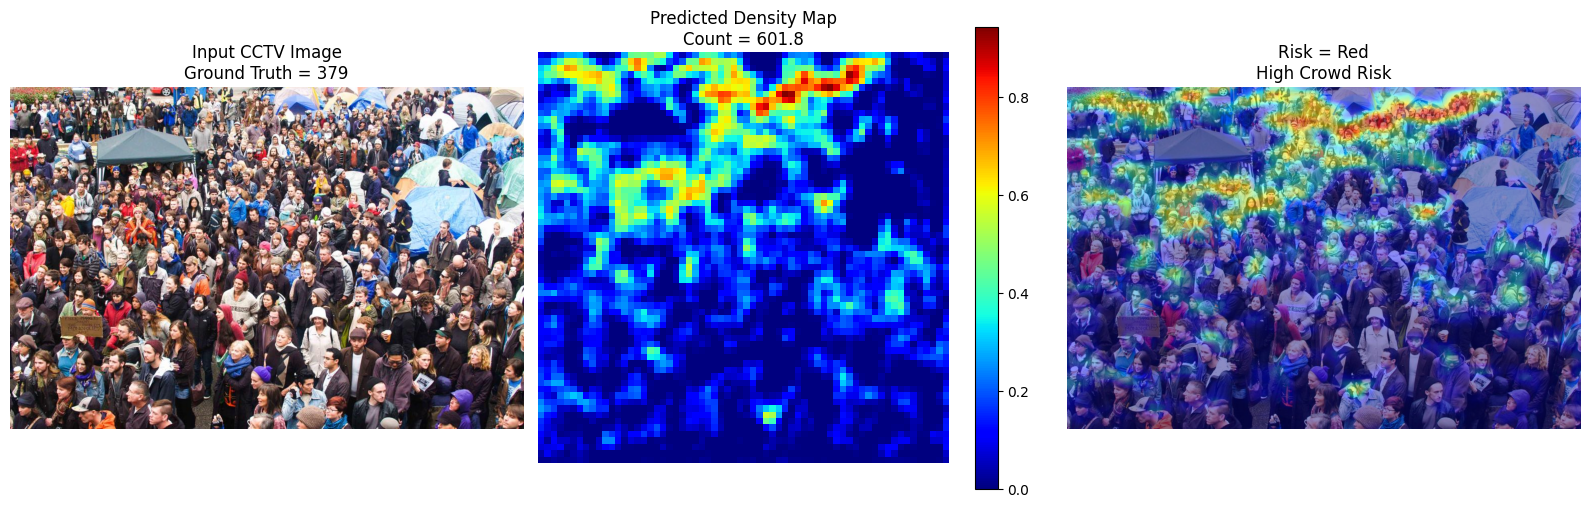

In [47]:
# ============================================================
# CELL 47 — VISUALIZE BEST MODEL
# ============================================================

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)

plt.imshow(original_image)

plt.title(
    f"Input CCTV Image\n"
    f"Ground Truth = {gt_count:.0f}"
)

plt.axis("off")


plt.subplot(1, 3, 2)

plt.imshow(
    pred_density.squeeze(),
    cmap="jet"
)

plt.colorbar()

plt.title(
    f"Predicted Density Map\n"
    f"Count = {pred_count:.1f}"
)

plt.axis("off")


plt.subplot(1, 3, 3)

plt.imshow(original_image)

plt.imshow(
    cv2.resize(
        pred_density.squeeze(),
        (
            original_image.shape[1],
            original_image.shape[0]
        )
    ),
    cmap="jet",
    alpha=0.45
)

plt.title(
    f"Risk = {risk}\n"
    f"{risk_description(risk)}"
)

plt.axis("off")

plt.tight_layout()
plt.show()

In [48]:
# ============================================================
# CELL 48 — GRAD-CAM FOR CROWD COUNTING
# ============================================================

def find_last_conv_layer(model):

    for layer in reversed(model.layers):

        if isinstance(
            layer,
            tf.keras.layers.Conv2D
        ):
            return layer.name

    raise ValueError(
        "No Conv2D layer found."
    )


last_conv_layer_name = find_last_conv_layer(
    best_model
)

print(
    "Last convolutional layer:",
    last_conv_layer_name
)

Last convolutional layer: conv2d_8


In [49]:
# ============================================================
# CELL 49 — GRAD-CAM HEATMAP
# ============================================================

grad_model = tf.keras.models.Model(
    inputs=best_model.inputs,
    outputs=[
        best_model.get_layer(
            last_conv_layer_name
        ).output,
        best_model.output
    ]
)


def make_gradcam_heatmap(
    image_array
):

    image_tensor = tf.convert_to_tensor(
        image_array,
        dtype=tf.float32
    )

    with tf.GradientTape() as tape:

        conv_output, prediction = (
            grad_model(
                image_tensor
            )
        )

        loss = tf.reduce_sum(
            prediction
        )

    gradients = tape.gradient(
        loss,
        conv_output
    )

    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    conv_output = conv_output[0]

    heatmap = tf.reduce_sum(
        conv_output *
        pooled_gradients,
        axis=-1
    )

    heatmap = tf.maximum(
        heatmap,
        0
    )

    max_value = tf.reduce_max(
        heatmap
    )

    heatmap = tf.where(
        max_value > 0,
        heatmap / max_value,
        heatmap
    )

    return heatmap.numpy()

In [50]:
# ============================================================
# CELL 50 — GENERATE GRAD-CAM
# ============================================================

image_for_model, _ = (
    preprocess_image_density(
        original_image,
        generate_density_map(
            original_image.shape,
            load_image_and_points(
                selected_path
            )[1]
        )
    )
)

image_batch = np.expand_dims(
    image_for_model,
    axis=0
)

heatmap = make_gradcam_heatmap(
    image_batch
)

heatmap = cv2.resize(
    heatmap,
    (
        original_image.shape[1],
        original_image.shape[0]
    )
)

print("Grad-CAM generated.")

Grad-CAM generated.


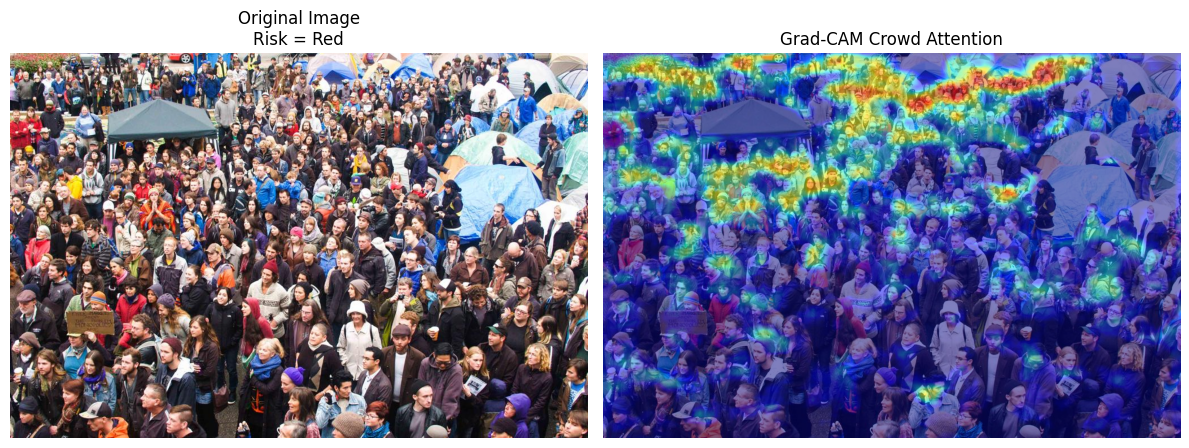

In [51]:
# ============================================================
# CELL 51 — GRAD-CAM VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.imshow(original_image)

plt.title(
    f"Original Image\nRisk = {risk}"
)

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(original_image)

plt.imshow(
    heatmap,
    cmap="jet",
    alpha=0.5
)

plt.title(
    "Grad-CAM Crowd Attention"
)

plt.axis("off")

plt.tight_layout()
plt.show()

In [52]:
# ============================================================
# CELL 52 — INSTALL LIME
# ============================================================

!pip -q install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [53]:
# ============================================================
# CELL 53 — LIME IMPORTS
# ============================================================

from lime import lime_image
from skimage.segmentation import mark_boundaries

print("LIME imported.")

LIME imported.


In [54]:
# ============================================================
# CELL 54 — LIME RISK PREDICTION WRAPPER
# ============================================================

def predict_risk_probabilities(
    images
):

    results = []

    for image in images:

        image = image.astype(
            np.float32
        )

        density_prediction = (
            best_model.predict(
                np.expand_dims(
                    image,
                    axis=0
                ),
                verbose=0
            )[0]
        )

        count = float(
            density_prediction.sum()
        )

        if count < 100:

            probabilities = [
                0.90,
                0.08,
                0.02
            ]

        elif count < 300:

            probabilities = [
                0.10,
                0.80,
                0.10
            ]

        else:

            probabilities = [
                0.02,
                0.08,
                0.90
            ]

        results.append(
            probabilities
        )

    return np.array(
        results
    )

In [55]:
# ============================================================
# CELL 55 — LIME EXPLANATION
# ============================================================

lime_explainer = (
    lime_image.LimeImageExplainer()
)

lime_explanation = (
    lime_explainer.explain_instance(
        image_for_model,
        predict_risk_probabilities,
        top_labels=3,
        hide_color=0,
        num_samples=200
    )
)

print("LIME explanation generated.")

  0%|          | 0/200 [00:00<?, ?it/s]

LIME explanation generated.


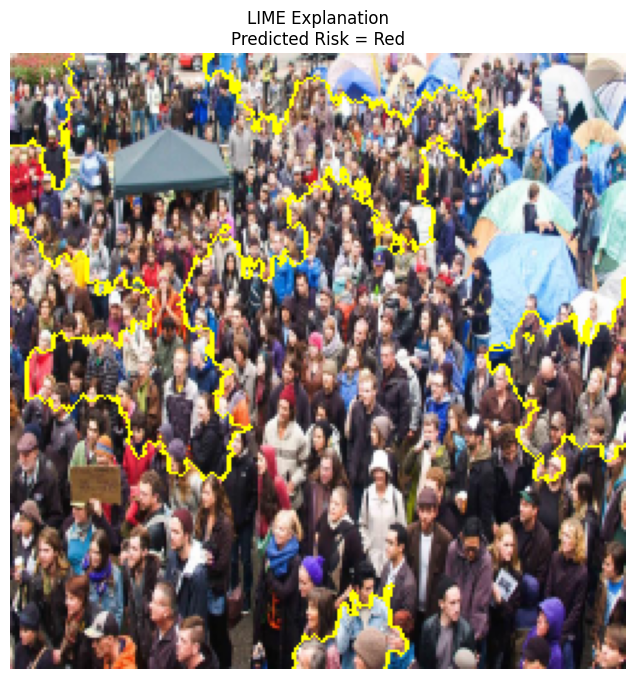

In [56]:
# ============================================================
# CELL 56 — VISUALIZE LIME
# ============================================================

top_label = (
    lime_explanation.top_labels[0]
)

lime_image_output, lime_mask = (
    lime_explanation.get_image_and_mask(
        top_label,
        positive_only=True,
        num_features=10,
        hide_rest=False
    )
)

plt.figure(figsize=(8, 8))

plt.imshow(
    mark_boundaries(
        lime_image_output,
        lime_mask
    )
)

plt.title(
    f"LIME Explanation\n"
    f"Predicted Risk = {risk}"
)

plt.axis("off")

plt.show()

In [57]:
# ============================================================
# CELL 57 — INSTALL SHAP
# ============================================================

!pip -q install shap

In [58]:
# ============================================================
# CELL 58 — SHAP
# ============================================================

import shap

print(
    "SHAP version:",
    shap.__version__
)

SHAP version: 0.52.0


In [59]:
# ============================================================
# CELL 59 — SHAP COUNT MODEL
# ============================================================

count_output = tf.keras.layers.Lambda(
    lambda x: tf.reduce_sum(
        x,
        axis=[1, 2, 3]
    ),
    name="crowd_count"
)(
    best_model.output
)

count_model = tf.keras.models.Model(
    inputs=best_model.input,
    outputs=count_output
)

print(
    "SHAP count model output:",
    count_model.output_shape
)

SHAP count model output: (None,)


In [60]:
# ============================================================
# CELL 60 — SHAP BACKGROUND DATA
# ============================================================

background_generator = data_generator(
    train_paths,
    batch_size=4,
    shuffle=False
)

background_images, _ = next(
    background_generator
)

print(
    "SHAP background shape:",
    background_images.shape
)

SHAP background shape: (4, 256, 256, 3)


In [61]:
# ============================================================
# CELL 61 — SHAP EXPLAINER
# ============================================================

shap_explainer = shap.GradientExplainer(
    count_model,
    background_images
)

print("SHAP explainer created.")

SHAP explainer created.


In [62]:
# CELL 62 — SHAP VALUES

print("Generating SHAP values...")

# Make sure the image has the correct shape and type
image_input = np.asarray(
    np.expand_dims(image_for_model, axis=0),
    dtype=np.float32
)

print("Input shape:", image_input.shape)

# Generate SHAP values
shap_values = shap_explainer.shap_values(image_input)

print("SHAP values generated successfully.")

Generating SHAP values...
Input shape: (1, 256, 256, 3)


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(1, 256, 256, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 256, 256, 3))']
  warnings.warn(msg)


SHAP values generated successfully.


In [63]:
# ============================================================
# CELL 63 — SHAP VISUALIZATION
# ============================================================

if isinstance(
    shap_values,
    list
):

    shap_array = shap_values[0]

else:

    shap_array = shap_values

print(
    "SHAP shape:",
    np.array(shap_array).shape
)

SHAP shape: (1, 256, 256, 3, 1)


In [64]:
# ============================================================
# CELL 64 — SHAP HEATMAP (FINAL FIX)
# ============================================================

shap_array = np.asarray(shap_values)

print("Original SHAP shape:", shap_array.shape)

# Remove all dimensions having size 1
shap_array = np.squeeze(shap_array)

print("After squeeze:", shap_array.shape)

# Expected result:
# (256, 256, 3)

if shap_array.ndim == 3:

    # H x W x Channels
    shap_heatmap = np.mean(
        np.abs(shap_array),
        axis=-1
    )

elif shap_array.ndim == 2:

    shap_heatmap = np.abs(
        shap_array
    )

else:

    raise ValueError(
        f"Unexpected SHAP shape after squeeze: "
        f"{shap_array.shape}"
    )

# Convert to float32
shap_heatmap = np.asarray(
    shap_heatmap,
    dtype=np.float32
)

print(
    "Heatmap before resize:",
    shap_heatmap.shape
)

# Original image dimensions
target_height = int(
    original_image.shape[0]
)

target_width = int(
    original_image.shape[1]
)

# Resize SHAP heatmap
shap_heatmap = cv2.resize(
    shap_heatmap,
    (target_width, target_height),
    interpolation=cv2.INTER_LINEAR
)

# Normalize to [0, 1]
shap_min = shap_heatmap.min()
shap_max = shap_heatmap.max()

if shap_max > shap_min:

    shap_heatmap = (
        shap_heatmap - shap_min
    ) / (
        shap_max - shap_min
    )

else:

    shap_heatmap = np.zeros_like(
        shap_heatmap
    )

print(
    "Final SHAP heatmap shape:",
    shap_heatmap.shape
)

print(
    "SHAP heatmap generated successfully."
)

Original SHAP shape: (1, 256, 256, 3, 1)
After squeeze: (256, 256, 3)
Heatmap before resize: (256, 256)
Final SHAP heatmap shape: (683, 1024)
SHAP heatmap generated successfully.


In [65]:
# ============================================================
# CELL 65 — EXPLAINABILITY REGION ANALYSIS
# ============================================================

def analyze_heatmap(
    heatmap
):

    h, w = heatmap.shape

    regions = {

        "Top-Left":
            heatmap[:h//2, :w//2].mean(),

        "Top-Right":
            heatmap[:h//2, w//2:].mean(),

        "Bottom-Left":
            heatmap[h//2:, :w//2].mean(),

        "Bottom-Right":
            heatmap[h//2:, w//2:].mean()
    }

    strongest_region = max(
        regions,
        key=regions.get
    )

    return regions, strongest_region


gradcam_regions, strongest_gradcam_region = (
    analyze_heatmap(
        heatmap
    )
)

shap_regions, strongest_shap_region = (
    analyze_heatmap(
        shap_heatmap
    )
)

print(
    "Strongest Grad-CAM region:",
    strongest_gradcam_region
)

print(
    "Strongest SHAP region:",
    strongest_shap_region
)

Strongest Grad-CAM region: Top-Left
Strongest SHAP region: Top-Left


In [66]:
# ============================================================
# CELL 66 — LIME REGION STATISTICS
# ============================================================

lime_region_count = int(
    np.sum(
        lime_mask > 0
    )
)

print(
    "Important LIME pixels:",
    lime_region_count
)

Important LIME pixels: 18299


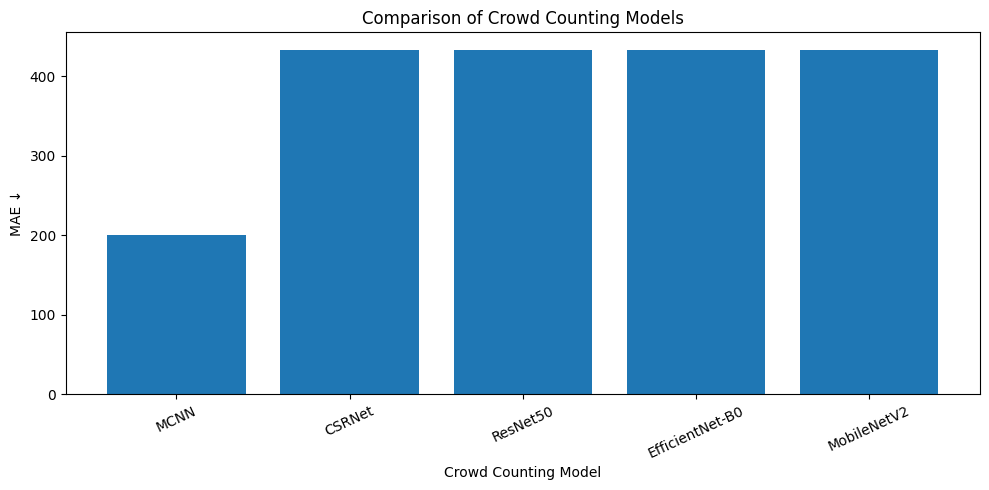

In [67]:
# ============================================================
# CELL 67 — MODEL COMPARISON VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["MAE"]
)

plt.xlabel("Crowd Counting Model")
plt.ylabel("MAE ↓")
plt.title(
    "Comparison of Crowd Counting Models"
)

plt.xticks(
    rotation=25
)

plt.tight_layout()
plt.show()

In [68]:
# ============================================================
# CELL 68 — FINAL SYSTEM OUTPUT
# ============================================================

final_risk = classify_risk(
    pred_count
)

print("=" * 60)
print("EXPLAINABLE AI CROWD RISK PREDICTION")
print("=" * 60)

print(
    "Selected Model:",
    best_model_name
)

print(
    "Ground Truth Count:",
    int(gt_count)
)

print(
    "Predicted Crowd Count:",
    round(pred_count, 2)
)

print(
    "Risk Level:",
    final_risk
)

print(
    "Risk Description:",
    risk_description(final_risk)
)

print(
    "Grad-CAM Important Region:",
    strongest_gradcam_region
)

print(
    "SHAP Important Region:",
    strongest_shap_region
)

print(
    "LIME Important Pixels:",
    lime_region_count
)

print("=" * 60)

EXPLAINABLE AI CROWD RISK PREDICTION
Selected Model: MCNN
Ground Truth Count: 379
Predicted Crowd Count: 601.78
Risk Level: Red
Risk Description: High Crowd Risk
Grad-CAM Important Region: Top-Left
SHAP Important Region: Top-Left
LIME Important Pixels: 18299


In [69]:
# ============================================================
# CELL 69 — SAVE MODEL COMPARISON RESULTS
# ============================================================

comparison_df.to_csv(
    "crowd_counting_model_comparison.csv",
    index=False
)

print(
    "Saved:",
    "crowd_counting_model_comparison.csv"
)

Saved: crowd_counting_model_comparison.csv


In [70]:
# ============================================================
# CELL 70 — SAVE BEST MODEL
# ============================================================

best_model.save(
    "best_crowd_risk_model.keras"
)

print(
    "Saved best model:",
    best_model_name
)

Saved best model: MCNN


In [71]:
# ============================================================
# CELL 71 — FINAL RESULT TABLE
# ============================================================

final_results = comparison_df.copy()

final_results["Risk Task"] = (
    "Green / Orange / Red"
)

display(
    final_results
)

,Model,MAE,RMSE,Inference Time (s),Risk Task
0,MCNN,200.402226,269.316862,0.083485,Green / Orange / Red
1,CSRNet,433.307692,559.188865,0.113968,Green / Orange / Red
2,ResNet50,433.307692,559.188865,0.116191,Green / Orange / Red
3,EfficientNet-B0,433.307692,559.188865,0.144367,Green / Orange / Red
4,MobileNetV2,433.307692,559.188865,0.145309,Green / Orange / Red


In [72]:
# ============================================================
# CELL 72 — FINAL SUMMARY
# ============================================================

print("PROJECT COMPLETED")
print()
print("Models compared:")
print("1. MCNN")
print("2. CSRNet")
print("3. ResNet50")
print("4. EfficientNet-B0")
print("5. MobileNetV2")
print()
print("Counting metrics:")
print("MAE")
print("RMSE")
print("Inference Time")
print()
print("Risk levels:")
print("Green  = Safe")
print("Orange = Moderate Risk")
print("Red    = High Crowd Risk")
print()
print("Explainable AI:")
print("Grad-CAM")
print("LIME")
print("SHAP")

PROJECT COMPLETED

Models compared:
1. MCNN
2. CSRNet
3. ResNet50
4. EfficientNet-B0
5. MobileNetV2

Counting metrics:
MAE
RMSE
Inference Time

Risk levels:
Green  = Safe
Orange = Moderate Risk
Red    = High Crowd Risk

Explainable AI:
Grad-CAM
LIME
SHAP
